# C7 — Secondary Holdout Report

**Protocol:** `v1.0.0`  
**Protocol hash:** `d42337690181f1054297f514934ad0c98bb718223bc06d8de5569f40a184ee32`

Notebook ini merupakan presentation layer *read-only* untuk satu evaluasi official NIH test. Hasil diposisikan sebagai **secondary holdout with prior exposure**; bukti komparatif utama tetap berasal dari patient-level five-fold OOF pada official training pool. Notebook tidak melakukan fitting, tuning, checkpoint selection, atau akses test baru.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'run_experiment.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.reporting.canonical import load_canonical_context, pooled_metrics

context = load_canonical_context(PROJECT_ROOT)
holdout_dir = context.protocol_dir / 'secondary_holdout'
assert (holdout_dir / '_SUCCESS').is_file(), 'C7 secondary holdout belum lengkap'
summary = json.loads((holdout_dir / 'summary.json').read_text(encoding='utf-8'))
receipt = json.loads((holdout_dir / 'official_test_access_receipt.json').read_text(encoding='utf-8'))
manifest_meta = json.loads((holdout_dir / 'official_test_manifest.json').read_text(encoding='utf-8'))
disclosure = json.loads((holdout_dir / 'prior_exposure_disclosure.json').read_text(encoding='utf-8'))
assert summary['status'] == 'COMPLETE'
assert summary['access_event_id'] == receipt['access_event_id'] == disclosure['access_event_id']
assert summary['protocol_hash'] == context.protocol_hash
pd.DataFrame([{
    'protocol_status': context.protocol['status'],
    'protocol_hash': context.protocol_hash,
    'access_event_id': receipt['access_event_id'],
    'images': manifest_meta['images'],
    'patients': manifest_meta['patients'],
    'abnormal_prevalence': manifest_meta['abnormal_prevalence'],
    'role': disclosure['official_partition_role'],
}])

,protocol_status,protocol_hash,access_event_id,images,patients,abnormal_prevalence,role
0,FROZEN,d42337690181f1054297f514934ad0c98bb718223bc06d...,1fd6844c-a989-49c5-84d6-5e44a4127b9f,25596,2797,0.614744,secondary holdout with prior exposure


## Audit akses tunggal, coverage, dan provenance

Prediksi lokal diperiksa terhadap immutable official-test manifest. Seluruh skenario harus memiliki urutan citra, Patient ID, dan label yang sama. Metrik diregenerasi dan harus sama dengan `summary.json`. Notebook hanya membaca manifest yang telah dimaterialisasi pada event C7; ia tidak membaca ulang official test list.

In [2]:
official_manifest = pd.read_csv(holdout_dir / 'official_test_manifest.csv').sort_values('image_index').reset_index(drop=True)
assert len(official_manifest) == manifest_meta['images']
assert official_manifest['patient_id'].nunique() == manifest_meta['patients']

predictions = {}
regenerated = {}
for scenario in ('S1', 'S2', 'S3'):
    path = holdout_dir / scenario / 'predictions.csv'
    frame = pd.read_csv(path).sort_values('image_index').reset_index(drop=True)
    assert set(frame['split']) == {'official_test_secondary_prior_exposure'}
    assert set(frame['protocol_hash'].astype(str)) == {context.protocol_hash}
    pd.testing.assert_frame_equal(
        frame[['image_index', 'patient_id', 'true_label']],
        official_manifest[['image_index', 'patient_id', 'true_label']],
        check_dtype=False,
        obj=f'C7 coverage {scenario}',
    )
    metrics = pooled_metrics(frame)
    reported = summary['scenarios'][scenario]['metrics']
    for key in ('roc_auc', 'average_precision', 'brier_score', 'accuracy', 'precision', 'sensitivity', 'specificity', 'f1'):
        assert abs(metrics[key] - reported[key]) < 1e-12, (scenario, key)
    predictions[scenario] = frame
    regenerated[scenario] = metrics

artifact_manifest = json.loads((holdout_dir / 'artifact_manifest.json').read_text(encoding='utf-8'))
checksum_errors = []
for relative, expected in artifact_manifest['artifacts'].items():
    path = context.protocol_dir / relative
    observed = hashlib.sha256(path.read_bytes()).hexdigest()
    if observed != expected['sha256'] or path.stat().st_size != expected['bytes']:
        checksum_errors.append(relative)
assert not checksum_errors, checksum_errors
print(f"Audit PASS: {len(official_manifest):,} images, {official_manifest['patient_id'].nunique():,} patients, {len(artifact_manifest['artifacts'])} immutable artifacts.")

Audit PASS: 25,596 images, 2,797 patients, 17 immutable artifacts.


## Aggregate secondary-holdout metrics

ROC-AUC dan Average Precision merupakan metrik prediktif utama. Metrik ambang 0,5 dan Brier score dilaporkan sebagai analisis sekunder/diagnostik. Karena weighted BCE digunakan, keluaran sigmoid disebut skor model dan tidak diklaim sebagai probabilitas klinis terkalibrasi.

In [3]:
metric_table = pd.DataFrame.from_dict(regenerated, orient='index')[
    ['roc_auc', 'average_precision', 'brier_score', 'accuracy', 'precision', 'sensitivity', 'specificity', 'f1']
]
metric_table.index.name = 'scenario'
display(metric_table.style.format('{:.6f}'))

,roc_auc,average_precision,brier_score,accuracy,precision,sensitivity,specificity,f1
scenario,,,,,,,,
S1,0.617793,0.685066,0.226724,0.651117,0.666178,0.866857,0.306865,0.753383
S2,0.710535,0.764908,0.205502,0.700930,0.720886,0.837941,0.482304,0.775018
S3,0.712527,0.765530,0.202772,0.704837,0.724479,0.838894,0.490924,0.777500


In [4]:
secondary_effect = pd.DataFrame([{
    'estimand': 'secondary S3 minus S2',
    'delta_roc_auc': regenerated['S3']['roc_auc'] - regenerated['S2']['roc_auc'],
    'delta_average_precision': regenerated['S3']['average_precision'] - regenerated['S2']['average_precision'],
    'delta_brier_score': regenerated['S3']['brier_score'] - regenerated['S2']['brier_score'],
}])
display(secondary_effect.style.format({column: '{:+.6f}' for column in secondary_effect.columns if column != 'estimand'}))

,estimand,delta_roc_auc,delta_average_precision,delta_brier_score
0,secondary S3 minus S2,+0.001992,+0.000622,-0.002730


## Diagnostic calibration

Reliability diagram menggunakan 10 uniform bins. Empty bins tetap kosong/NaN dan jumlah sampel setiap bin dipertahankan pada artifact.

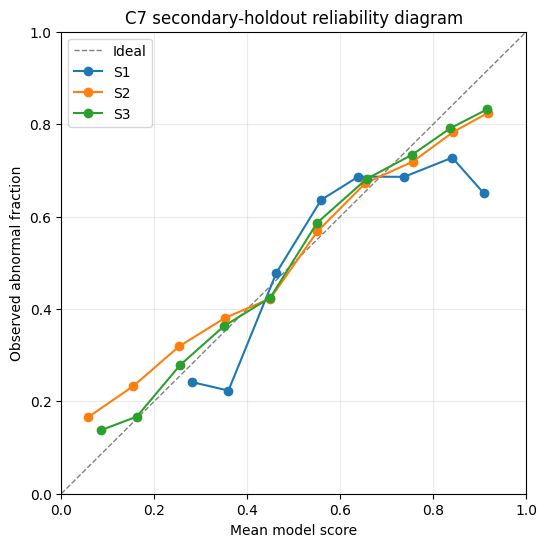

In [5]:
fig, axis = plt.subplots(figsize=(6, 6))
axis.plot([0, 1], [0, 1], '--', color='grey', linewidth=1, label='Ideal')
for scenario in ('S1', 'S2', 'S3'):
    calibration = pd.read_csv(holdout_dir / scenario / 'calibration.csv')
    assert calibration['count'].sum() == manifest_meta['images']
    valid = calibration['count'] > 0
    axis.plot(calibration.loc[valid, 'mean_score'], calibration.loc[valid, 'fraction_positive'], marker='o', label=scenario)
axis.set(title='C7 secondary-holdout reliability diagram', xlabel='Mean model score', ylabel='Observed abnormal fraction', xlim=(0, 1), ylim=(0, 1))
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## Interpretasi

Pada secondary holdout, S3 memiliki ROC-AUC 0,712527 dan S2 0,710535, sehingga selisih titik S3−S2 adalah +0,001992. Arah ini konsisten dengan selisih OOF yang kecil, tetapi tidak mengubah kesimpulan utama: CI 95% patient-cluster bootstrap OOF untuk S3-D−S2 melintasi nol. Official NIH test pernah memengaruhi eksperimen eksploratif sebelum protocol freeze, sehingga hasil C7 tidak ditafsirkan sebagai estimasi generalisasi independen yang pristine dan tidak digunakan untuk tuning baru.